In [939]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from utils import * #only needed for xgboost
from friedman1 import *

import warnings
warnings.filterwarnings("ignore") #just to supress warnings

In [940]:
#Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per (target_instances, d), ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col=[0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by=['seed'] + config_cols)

    # aggregate over seeds
    agg = (df.groupby(config_cols, as_index=False)
             .agg(avg_rmse=('rmse', 'mean'),
                  #avg_mae=('val_mae', 'mean'),
                  n_seeds=('seed', 'nunique'),
                  d=('d', 'first')))

    # merge back on config_cols only (minimal fix)
    agg = agg.merge(df, on=config_cols, how='left')

    # sort globally by the fields that determine the ranking
    agg = agg.sort_values(by=['d', 'avg_rmse'], ascending=True)

    # select top-k per (target_instances, d)
    topk_df = agg.groupby(['d'], group_keys=False).head(k)

    # final compact output
    topk_d = topk_df[['d', 'avg_rmse', 'rmse', 'mae']]

    return topk_d, agg




In [941]:
#Read data (remove v = 0.05 because we chose not to include it)
size = 200
data_ttb = pd.read_csv(f'results_{size}/ttb_LS.csv')
data_ttb_ = pd.read_csv(f'results_{size}/ttb_LS_936937.csv')
data_ttb__ = pd.read_csv(f'results_{size}/ttb_LS_934935.csv')
data_ttb___ = pd.read_csv(f'results_{size}/ttb_LS_938939.csv')
data_ttb = pd.concat([data_ttb, data_ttb_])
data_ttb = pd.concat([data_ttb, data_ttb__])
data_ttb = pd.concat([data_ttb, data_ttb___])

data_xgboost = pd.read_csv(f'results_{size}/xgb.csv')
#data_xgboost = data_xgboost[data_xgboost['seed'] < 932]

data_xgboost_warmstart = pd.read_csv(f'results_{size}/xgb_warmstart.csv')
#data_xgboost_warmstart = data_xgboost_warmstart[data_xgboost_warmstart['seed'] < 932]

data_xgboost_pooled = pd.read_csv(f'results_{size}/xgb_naive.csv')
#data_xgboost_pooled = data_xgboost_pooled[data_xgboost_pooled['seed'] < 932]

data_two_trada = pd.read_csv('results_200/two_trada.csv')
data_ttb = data_ttb.drop_duplicates(subset = ['seed', 'd', 'v', 'target_tree_size', 'source_tree_size', 'm_0', 'k'])
len(data_ttb)

3600

# Here we make final vizes!

<Figure size 700x700 with 0 Axes>

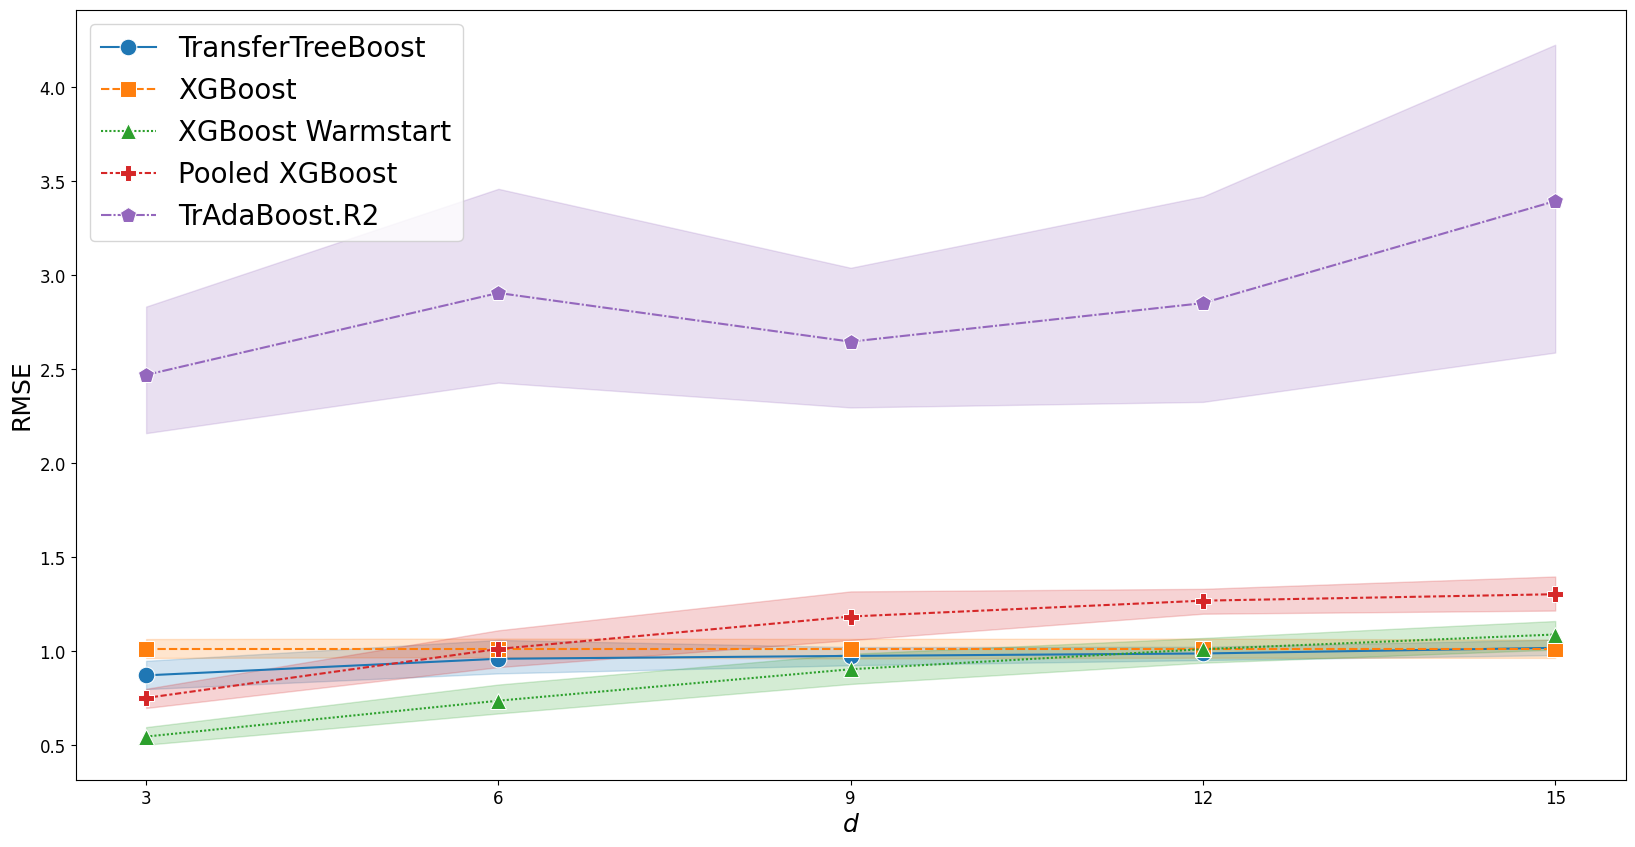

In [942]:

plt.figure(figsize = (7,7))

import matplotlib as mpl

best_ttb, best_ttb_params = topk_per_d_per_method(
    data_ttb,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=10
)
best_ttb['Method'] = 'TransferTreeBoost'

best_xgboost, best_xgboost_params = topk_per_d_per_method(
    data_xgboost,
    ['d', 'v', 'target_tree_size'], k=10
)
best_xgboost['Method'] = 'XGBoost'

best_xgboost_warmstart, best_xgboost_warmstart_params = topk_per_d_per_method(
    data_xgboost_warmstart,
    ['d', 'v', 'target_tree_size'], k=10
)
best_xgboost_warmstart['Method'] = 'XGBoost Warmstart'

best_xgboost_pooled, best_xgboost_pooled_params = topk_per_d_per_method(
    data_xgboost_pooled,
    ['d', 'v', 'target_tree_size'], k=10
)
best_xgboost_pooled['Method'] = 'Pooled XGBoost'

best_trada, best_trada_params = topk_per_d_per_method(
    data_two_trada,
    ['d', 'lr', 'n_estimators', 'tree_size'], k=10
)
best_trada['Method'] = 'TrAdaBoost.R2'


# create new df for viz
df = pd.concat([best_ttb, best_xgboost])
df = pd.concat([df, best_xgboost_warmstart])
df = pd.concat([df, best_xgboost_pooled])
df = pd.concat([df, best_trada])
plt.figure(figsize = (20,10))
sns.lineplot(data=df, x='d', y='rmse', hue='Method', style = 'Method', markers = {'TransferTreeBoost':'o',
                                                                                  'XGBoost': 's', 'XGBoost Warmstart': '^',
                                                                                   'Pooled XGBoost': 'P', 'TrAdaBoost.R2': 'p'
                                                                                    },
                                                                                    markersize = 12)
plt.legend(title = None, fontsize = 20, title_fontsize = 20)
plt.xticks([3, 6, 9, 12, 15], size = 12)  # positions of ticks
plt.yticks(size = 12)  # positions of ticks
plt.xlabel('$d$', fontsize = 18)
plt.ylabel('RMSE', fontsize = 18)
plt.savefig('vizes/final_with_trada.png', bbox_inches = 'tight', pad_inches = 0.1, dpi = 500)


In [943]:
(1.24 + 1.21 + 1.26 + 1.33 + 1.39) / 5

1.286

In [944]:
best_ttb_params[70:100]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,d,Unnamed: 0,seed,method,epochs,val_rmse,val_mae,rmse,mae
680,0.3,3,2,0.0,0.5,0.918325,10,3,69,930,LSTransferTreeBoost,1000,0.740099,0.587764,0.724347,0.564973
681,0.3,3,2,0.0,0.5,0.918325,10,3,429,931,LSTransferTreeBoost,1000,1.067178,0.837618,1.091973,0.858767
682,0.3,3,2,0.0,0.5,0.918325,10,3,789,932,LSTransferTreeBoost,1000,0.899189,0.711594,0.830824,0.651873
683,0.3,3,2,0.0,0.5,0.918325,10,3,1149,933,LSTransferTreeBoost,1000,0.821682,0.644115,0.881695,0.673582
684,0.3,3,2,0.0,0.5,0.918325,10,3,1509,934,LSTransferTreeBoost,1000,1.010722,0.781672,0.991759,0.773794
685,0.3,3,2,0.0,0.5,0.918325,10,3,1869,935,LSTransferTreeBoost,1000,0.928719,0.725568,0.991039,0.764757
686,0.3,3,2,0.0,0.5,0.918325,10,3,69,936,LSTransferTreeBoost,1000,0.840212,0.659643,0.831224,0.667436
687,0.3,3,2,0.0,0.5,0.918325,10,3,429,937,LSTransferTreeBoost,1000,0.951173,0.767357,0.897751,0.709081
688,0.3,3,2,0.0,0.5,0.918325,10,3,69,938,LSTransferTreeBoost,1000,0.857125,0.681181,0.866840,0.683207
689,0.3,3,2,0.0,0.5,0.918325,10,3,429,939,LSTransferTreeBoost,1000,1.082461,0.851409,1.075799,0.824111


In [945]:
best_xgboost_pooled_params

,v,target_tree_size,avg_rmse,n_seeds,d,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae
570,0.25,2.0,0.752809,10,3.0,57,930.0,0.657355,0.526888,0.635509,0.506008
571,0.25,2.0,0.752809,10,3.0,442,931.0,0.742934,0.573692,0.729136,0.565924
572,0.25,2.0,0.752809,10,3.0,827,932.0,0.829374,0.665784,0.796840,0.625169
573,0.25,2.0,0.752809,10,3.0,1212,933.0,0.794317,0.624697,0.794829,0.623659
574,0.25,2.0,0.752809,10,3.0,1597,934.0,0.816664,0.639215,0.774730,0.616991
...,...,...,...,...,...,...,...,...,...,...,...
3085,0.05,1.0,3.222959,10,15.0,2233,935.0,3.945005,3.262432,4.136943,3.380961
3086,0.05,1.0,3.222959,10,15.0,2618,936.0,3.893189,3.144184,3.790356,3.036778
3087,0.05,1.0,3.222959,10,15.0,3003,937.0,1.305557,1.022900,1.308864,1.034766
3088,0.05,1.0,3.222959,10,15.0,3388,938.0,3.452848,2.746802,3.535101,2.774026


In [946]:
best_trada_params[best_trada_params['d'] == 9]

,lr,n_estimators,tree_size,avg_rmse,n_seeds,d,Unnamed: 0,seed,rmse,mae
1510,0.1,20.0,4.0,2.647321,10,9.0,151,930.0,2.847449,2.116738
1511,0.1,20.0,4.0,2.647321,10,9.0,511,931.0,2.256221,1.711188
1512,0.1,20.0,4.0,2.647321,10,9.0,871,932.0,2.234048,1.755759
1513,0.1,20.0,4.0,2.647321,10,9.0,1231,933.0,3.653275,2.919664
1514,0.1,20.0,4.0,2.647321,10,9.0,1591,934.0,2.703988,2.181825
...,...,...,...,...,...,...,...,...,...,...
1965,1.0,20.0,1.0,7.105983,10,9.0,1996,935.0,8.156022,6.874108
1966,1.0,20.0,1.0,7.105983,10,9.0,2356,936.0,3.577555,2.974525
1967,1.0,20.0,1.0,7.105983,10,9.0,2716,937.0,4.612308,3.700483
1968,1.0,20.0,1.0,7.105983,10,9.0,3076,938.0,6.726658,5.644019
